In [ ]:
#@title Installation and importing packages
!pip install vina meeko rdkit gemmi pdbfixer openmm py3Dmol prody

import urllib.request            # automatic download of files from the internet

# Preparation of ligand
from rdkit import Chem
from meeko import MoleculePreparation, PDBQTWriterLegacy

# Preparation of protein
from pdbfixer import PDBFixer
from openmm.app import PDBFile

# Docking
from vina import Vina

# 3D visualization
import py3Dmol

# Coursework part from laboratory work 5

The A chain of 5HNR (human native 5-aminolaevulinic acid dehydratase) used as a receptor and the DAV (DELTA-AMINO VALERIC ACID) - as a ligand.

For submission, upload to GitHub the .dock4 file, three .pdbqt files generated in this Notebook (protein, ligand, result), and the Notebook itself.

#0. Doing it online

First, use the SwissDock server to run the docking process online: https://www.swissdock.ch/

Note that as the whole group will start the docking mostly at the same time, you will need to wait in a queue.

When it is done, download the result - you will need `.dock4` and the protein processed pdb file. To load the dock4 file into Pymol, you need to first install this plugin:

`https://github.com/unizar-flav/PyViewDock/releases/latest/download/PyViewDock.zip`

In PyMol, press `Plugin > Plugin Manager > Install New Plugin`, then put the link into the corresponding field and install the plugin. After that, you can just drap-and-drop the dock4 file into PyMol.

## 1. Ligand preparation

The formula for benzamidine is relatively simple and can be written in SMILES format.

Find the SMILES formula for benzamidine and insert it in place of `...`:

In [ ]:
smiles = "NCCCCC(=O)O"

Then, using the `Chem` subpackage from the `rdkit` package, you can generate the complete structure of this molecule:

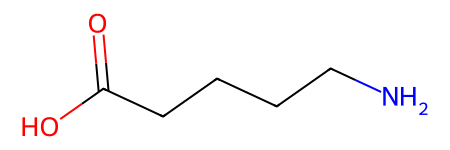

In [ ]:
mol = Chem.MolFromSmiles(smiles)
mol

There are no hydrogen atoms in the SMILES string; you need to add them:

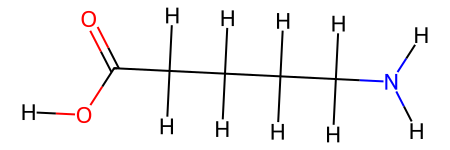

In [ ]:
mol = Chem.AddHs(mol)
mol

The molecule should be transferred to 3D space and further optimized:

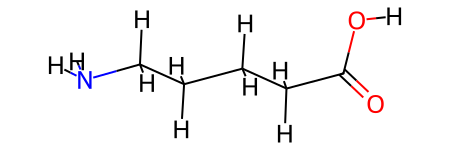

In [ ]:
Chem.AllChem.EmbedMolecule(mol, Chem.AllChem.ETKDGv3())
Chem.AllChem.MMFFOptimizeMolecule(mol)
mol

You can have an interactive 3D visualization of the molecule, using the `py3Dmol` package:

In [ ]:
view  = py3Dmol.view(
    data=Chem.MolToMolBlock(mol),
    style={"stick": {}, "sphere": {"scale": 0.3}}
)
view.zoomTo()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

You can then generate a PDBQT file using the `meeko` package:

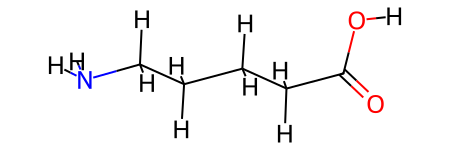

In [ ]:
preparator = MoleculePreparation()
mol_setups = preparator.prepare(mol)
# mol_setups is a list with a single element inside - we need to index it:
mol_setup = mol_setups[0]
mol_setup.mol

There is no difference in the molecular representation, but the ligand's PDBQT file must contain information about all of the molecule's bonds (e.g., some bonds may be rotatable, while others are not):

In [ ]:
mol_setup.bond_info

{(0,
  1): Bond(canon_id=(0, 1), index1=0, index2=1, rotatable=True, breakable=False),
 (1,
  2): Bond(canon_id=(1, 2), index1=1, index2=2, rotatable=True, breakable=False),
 (2,
  3): Bond(canon_id=(2, 3), index1=2, index2=3, rotatable=True, breakable=False),
 (3,
  4): Bond(canon_id=(3, 4), index1=3, index2=4, rotatable=True, breakable=False),
 (4,
  5): Bond(canon_id=(4, 5), index1=4, index2=5, rotatable=True, breakable=False),
 (5,
  6): Bond(canon_id=(5, 6), index1=5, index2=6, rotatable=False, breakable=False),
 (5,
  7): Bond(canon_id=(5, 7), index1=5, index2=7, rotatable=True, breakable=False),
 (0,
  8): Bond(canon_id=(0, 8), index1=0, index2=8, rotatable=False, breakable=False),
 (0,
  9): Bond(canon_id=(0, 9), index1=0, index2=9, rotatable=False, breakable=False),
 (1,
  10): Bond(canon_id=(1, 10), index1=1, index2=10, rotatable=False, breakable=False),
 (1,
  11): Bond(canon_id=(1, 11), index1=1, index2=11, rotatable=False, breakable=False),
 (2,
  12): Bond(canon_id=(2, 12

We create a PDBQT file using `PDBQTWriterLegacy` from `meeko`:

In [ ]:
pdbqt_string, is_ok, error_msg = PDBQTWriterLegacy.write_string(mol_setup)

if not is_ok:  # if an error happens
  print("Warning: ", error_msg)
else:
  print("PDBQT row was created:\n")
  print(pdbqt_string)

PDBQT row was created:

REMARK SMILES NCCCCC(=O)O
REMARK SMILES IDX 4 1 3 2 2 3 1 4 5 7 6 8 7 9 8 10
REMARK H PARENT 1 5 1 6 8 11
ROOT
ATOM      1  C   UNL     1       0.452   0.044   0.306  1.00  0.00     0.013 C 
ENDROOT
BRANCH   1   2
ATOM      2  C   UNL     1      -0.952  -0.332  -0.168  1.00  0.00     0.016 C 
BRANCH   2   3
ATOM      3  C   UNL     1      -2.016   0.145   0.819  1.00  0.00     0.077 C 
BRANCH   3   4
ATOM      4  N   UNL     1      -3.344  -0.230   0.349  1.00  0.00    -0.330 NA
ATOM      5  H   UNL     1      -3.531   0.218  -0.547  1.00  0.00     0.118 HD
ATOM      6  H   UNL     1      -4.045   0.126   0.998  1.00  0.00     0.118 HD
ENDBRANCH   3   4
ENDBRANCH   2   3
ENDBRANCH   1   2
BRANCH   1   7
ATOM      7  C   UNL     1       1.516  -0.436  -0.674  1.00  0.00     0.122 C 
BRANCH   7   8
ATOM      8  C   UNL     1       2.889  -0.073  -0.189  1.00  0.00     0.303 C 
ATOM      9  O   UNL     1       3.665  -0.807   0.399  1.00  0.00    -0.252 OA
BRANCH  

Save the PDBQT string as a file:

In [ ]:
with open("ligand.pdbqt", "w") as f:
    f.write(pdbqt_string)

## 2. Protein preparation

Preparing a protein is somewhat similar to preparing a ligand, as you also need to create a PDBQT file and add hydrogen atoms. However:
1. Proteins are not written using SMILES - the string would be incredibly long! Instead of SMILES, a PDB file obtained from a protein database is used.
1. PDB files often contain other molecules that will interfere with the docking process - like water molecules, ligands, residues from crystallization solutions, etc. These must be removed.

**Find a PDB code for the human native 5-aminolaevulinic acid dehydratase structure and enter it in place of `...`.** We can automatically retrieve the relevant structure from the internet using the `urllib` package, which is a standard Python module that allows you to make URL requests:

In [ ]:
pdb_code = '5HNR'

url = f"https://files.rcsb.org/download/{pdb_code}.pdb"
output_filename = f'{pdb_code}.pdb'

urllib.request.urlretrieve(url, output_filename)

('5HNR.pdb', <http.client.HTTPMessage at 0x7bd079b72c00>)

Now you need to use the `PDBFixer` package to ensure that the resulting structure is suitable for docking.

In [ ]:
fixer = PDBFixer(filename="5HNR.pdb")  # Enter the name of the automatically downloaded file

Check for any missing amino acids:

In [ ]:
fixer.findMissingResidues()
fixer.missingResidues  # will print out missing amino acid residues

{(0, 136): ['GLU', 'ASN'],
 (0, 326): ['GLU', 'GLU'],
 (1, 87): ['ASP', 'GLU', 'ARG', 'GLY', 'SER', 'ALA'],
 (1, 120): ['THR',
  'SER',
  'HIS',
  'GLY',
  'HIS',
  'CYS',
  'GLY',
  'LEU',
  'LEU',
  'SER',
  'GLU',
  'ASN',
  'GLY',
  'ALA',
  'PHE',
  'ARG'],
 (1, 190): ['LYS', 'SER', 'SER', 'PRO', 'ALA', 'PHE', 'GLY', 'ASP'],
 (1, 298): ['GLU', 'GLU']}

Check for the presence of non-standard amino acids:

In [ ]:
fixer.findNonstandardResidues()
fixer.nonstandardResidues

[]

If non-standard amino acids are found, `PDBfixer` will suggest replacing these amino acids with others (listed at the end of the lines). This can be done automatically:

In [ ]:
fixer.replaceNonstandardResidues()
fixer.nonstandardResidues

[]

All "hetero" molecules are removed, i.e., everything that is not a protein:

In [ ]:
fixer.removeHeterogens(keepWater=False)
# If something has been removed, it will be printed out

[<Residue 624 (ZN) of chain 2>,
 <Residue 625 (SO4) of chain 2>,
 <Residue 626 (DAV) of chain 2>,
 <Residue 627 (SO4) of chain 3>,
 <Residue 628 (HOH) of chain 4>,
 <Residue 629 (HOH) of chain 4>,
 <Residue 630 (HOH) of chain 4>,
 <Residue 631 (HOH) of chain 4>,
 <Residue 632 (HOH) of chain 4>,
 <Residue 633 (HOH) of chain 4>,
 <Residue 634 (HOH) of chain 4>,
 <Residue 635 (HOH) of chain 4>,
 <Residue 636 (HOH) of chain 4>,
 <Residue 637 (HOH) of chain 4>,
 <Residue 638 (HOH) of chain 4>,
 <Residue 639 (HOH) of chain 4>,
 <Residue 640 (HOH) of chain 4>,
 <Residue 641 (HOH) of chain 4>,
 <Residue 642 (HOH) of chain 4>,
 <Residue 643 (HOH) of chain 4>,
 <Residue 644 (HOH) of chain 4>,
 <Residue 645 (HOH) of chain 4>,
 <Residue 646 (HOH) of chain 4>,
 <Residue 647 (HOH) of chain 4>,
 <Residue 648 (HOH) of chain 4>,
 <Residue 649 (HOH) of chain 4>,
 <Residue 650 (HOH) of chain 4>,
 <Residue 651 (HOH) of chain 4>,
 <Residue 652 (HOH) of chain 4>,
 <Residue 653 (HOH) of chain 4>,
 <Residue 6

The system checks for missing atoms (hydrogen atoms are not counted):

In [ ]:
fixer.findMissingAtoms()
fixer.missingAtoms

{}

If certain atoms are missing, you need to run:
```python
fixer.addMissingAtoms()
```

Finally, we add hydrogen ions, and the pH must be indicated for this process. **Enter the correct pH value in place of `...`:**

In [ ]:
fixer.addMissingHydrogens(7)

We write the result to a PDB file using the `openmm` package.
- The `PDBQTWriterLegacy` method is not used for proteins, as it is intended only for ligands. A protein PDBQT file contains less information. We will generate it from a PDB file using a different method.

In [ ]:
PDBFile.writeFile(fixer.topology, fixer.positions,
                  open('receptor.pdb', 'w'))

**Open the generated file in PyMol and make sure it looks good and doesn't contain any water or other molecules!**

To save the PDBQT file, we will use Python code that was installed along with the `meeko` package. Unfortunately, the authors of this package did not make it possible to convert PDB files to PDBQT directly using Python functions. Therefore, we need to follow a few steps:
1. Find the path to the "mk_prepare_receptor.py" file:

In [ ]:
import shutil
script_path = shutil.which("mk_prepare_receptor.py")
script_path

'/usr/local/bin/mk_prepare_receptor.py'

2. Run the code in the found file using a Bash command. The example below will create a `receptor.pdbqt` file (`-o receptor` specifies the file name, and `-p` indicates that it should be a PDBQT file):

In [ ]:
!python {script_path} -i receptor.pdb -o receptor -p

@> 9684 atoms and 1 coordinate set(s) were parsed in 0.14s.

Files written:
receptor.pdbqt <-- static (i.e., rigid) receptor input file


Find and open this file and the PDB file in text mode. Note the differences.

## 3. Protein-ligand docking

For docking, we will use the Autodock Vina program, which is one of the most popular docking tools; it supports both rigid and flexible docking and can be used via Python:

In [ ]:
v = Vina(sf_name='vina')
v.set_receptor('receptor.pdbqt')  # enter the correct file name
v.set_ligand_from_file('ligand.pdbqt')  # enter the correct file name

The next step is to define the docking box. Open the receptor's PDBQT file in PyMol. For convenience, select the "surface" view to reveal the binding pocket. Then switch to the "spheres" or another convenient display mode and select several amino acids from different sides of the binding pocket (preferably 4 amino acids, one from each side). Use the PyMol command:
```
centerofmass sele
```
This will print the center coordinates (among all selected amino acids).

Additionally, get the minimum and maximum coordinates:
```
get_extent sele
```

See if it fits into the standard size of a docking box (20x20x20).

The docking box is typically set to cover a slightly larger area than the geometry of the docking center allows.

Enter the resulting numbers below (instead of the example provided) and run the command:

In [ ]:
v.compute_vina_maps(
    center=[38.551, 59.084, 56.994],
    box_size=[20, 20, 20]
)

Everything is now ready, and you can start the docking process (may take several seconds):

In [ ]:
v.dock(exhaustiveness=8, n_poses=5)  # The final result will feature the 5 best poses

Calculate the energy score:

In [ ]:
energy = v.score()
energy

array([-3.328, -4.301,  0.   ,  0.   ,  0.   , -0.042,  0.973, -0.042])

Among these numbers, the first is the overall energy score, and the others represent scores for specific components (you can find them in the  [documentation](https://autodock-vina.readthedocs.io/_/downloads/en/stable/pdf/)). Scores for all poses (lowest number = best result):

In [ ]:
v.energies()

array([[-3.328, -4.301, -0.042,  0.973, -0.042],
       [-3.297, -4.27 , -0.033,  0.964, -0.042],
       [-3.252, -4.21 , -0.035,  0.951, -0.042],
       [-3.223, -3.816, -0.392,  0.942, -0.042],
       [-2.991, -3.503, -0.405,  0.874, -0.042]])

Save all poses to a PDBQT file:

In [ ]:
v.write_poses('vina_out.pdbqt', n_poses=5)
# It won't let you overwrite the file if that name already exists!

Open the file you received in PyMol. Take a look at how the different ligand poses look like.